# Which Machine LEarning Models Are Sensitive To Outliers?

1. Naivye Bayes Classifier--- Not Sensitive To Outliers
2. SVM-------- Not Sensitive To Outliers
3. Linear Regression---------- Sensitive To Outliers
4. Logistic Regression------- Sensitive To Outliers
5. Decision Tree Regressor or Classifier---- Not Sensitive
6. Ensemble(RF,XGboost,GB)------- Not Sensitive
7. KNN---------------------------  Sensitive
8. Kmeans------------------------ Sensitive
9. Hierarichal------------------- Sensitive
10. PCA-------------------------- Sensitive
11. Neural Networks-------------- Sensitive

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df['Age'].isnull().sum()

np.int64(177)

In [7]:
import seaborn as sns

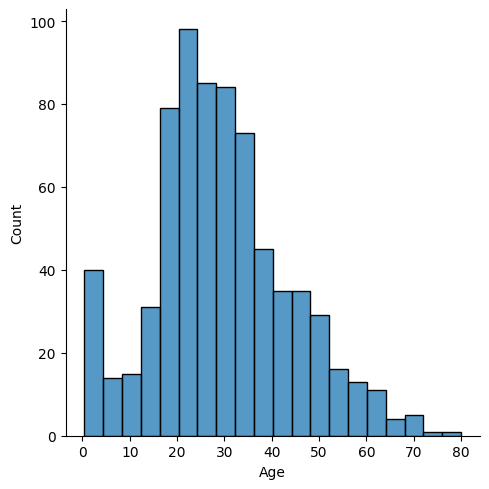

In [8]:
sns.displot(df['Age'].dropna())

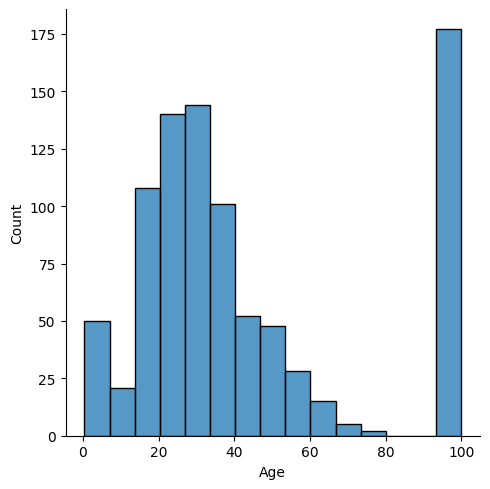

In [9]:
sns.displot(df['Age'].fillna(100))

<Axes: >

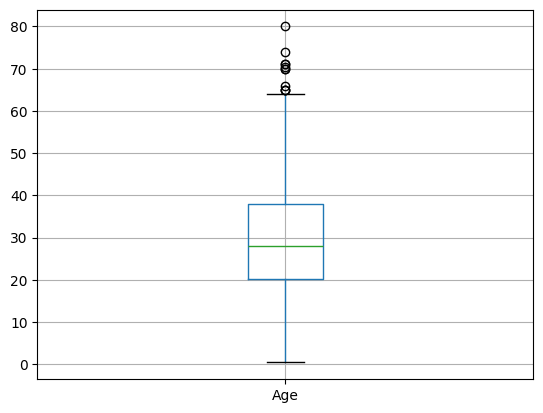

In [10]:
df.boxplot(column='Age')

In [12]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

# we use this if distribution is normal

In [13]:
##### Assuming Age follows A Gaussian Distribution we will calculate the boundaries which differentiates the outliers

upper_boundry = df['Age'].mean() + 3*df['Age'].std()
lower_boundry = df['Age'].mean() - 3*df['Age'].std()
print(lower_boundry) , print(upper_boundry) , print(df['Age'].mean())

-13.880374349943303
73.27860964406094
29.69911764705882


(None, None, None)

# If Features Are Skewed We Use the below Technique

<Axes: >

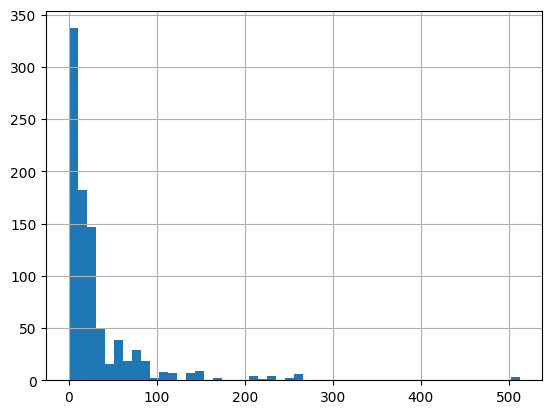

In [15]:
df['Fare'].hist(bins=50)

<Axes: >

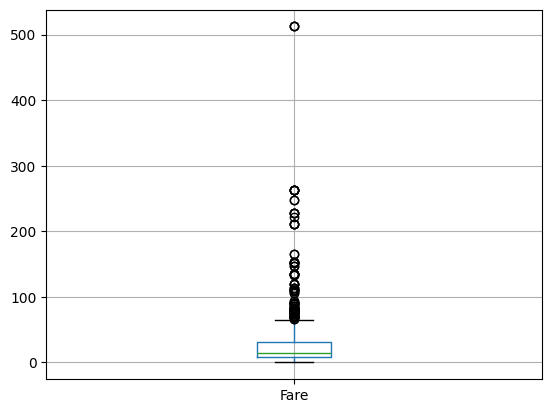

In [17]:
df.boxplot(column='Fare')

In [19]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [20]:
# lets compute the interquatile range
IQR = df.Fare.quantile(0.75) - df.Fare.quantile(0.25)

In [21]:
lower_bridge=df['Fare'].quantile(0.25)-(IQR*1.5)
upper_bridge=df['Fare'].quantile(0.75)+(IQR*1.5)
print(lower_bridge), print(upper_bridge)

-26.724
65.6344


(None, None)

In [22]:
#### Extreme outliers
lower_bridge=df['Fare'].quantile(0.25)-(IQR*3)
upper_bridge=df['Fare'].quantile(0.75)+(IQR*3)
print(lower_bridge), print(upper_bridge)

-61.358399999999996
100.2688


(None, None)

In [23]:
data=df.copy()

In [24]:

data.loc[data['Age']>=73,'Age']=73

In [25]:
data.loc[data['Fare']>=100,'Fare']=100

<Axes: >

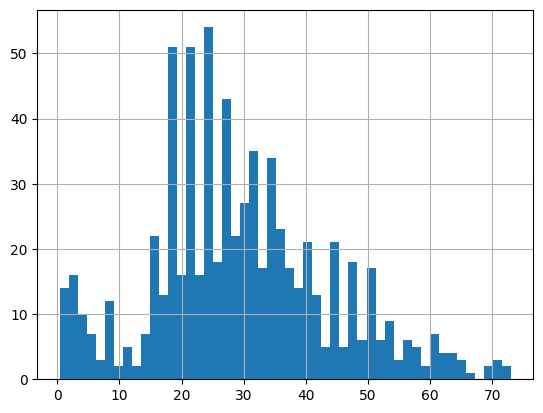

In [26]:
data.Age.hist(bins=50)

<Axes: >

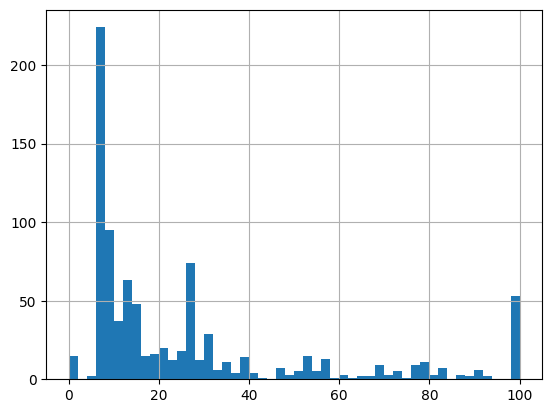

In [27]:
data['Fare'].hist(bins=50)

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data[['Age','Fare']].fillna(0),data['Survived'],train_size=0.3)

In [29]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
y_pred1 = classifier.predict_proba(X_test)


from sklearn.metrics import accuracy_score,roc_auc_score
print("Accuracy SCore : ", accuracy_score(y_test,y_pred))
print("Accuracy SCore : ", roc_auc_score(y_test,y_pred1[:,1]))

Accuracy SCore :  0.6858974358974359
Accuracy SCore :  0.6932837037439548
